In [58]:
# Put the project directory on the path to make sure we can import PyNitride
import sys, os
sys.path.append(os.path.abspath("../"))

In [59]:
%matplotlib notebook
import numpy as np
from scipy.linalg import norm
from pynitride import ParamDB, Material
from pynitride.bandstruct.kp import kp_6x6
from pynitride.bandstruct.reciprocal import generate_path
import matplotlib.pyplot as plt
pmdb=ParamDB(units='neu')
to_units=pmdb.to_units
q,hbar,m_e,nm=pmdb.get_constants("e,hbar,m_e,nm")
GaN=Material("GaN",pmdb=pmdb)
pa=np.pi/GaN['lattice.a']

In [60]:
GaN=Material("GaN")
AlN=Material("AlN")
a0=GaN['lattice.a']
c0=GaN['lattice.c']
a=AlN['lattice.a']
C13oC33=GaN['stiffness.C13']/GaN['stiffness.C33']
#C13oC33=108/374
st=(a-a0)/a0
sz=-2*C13oC33*st

In [61]:
import numpy as np
import scipy.linalg as la
from pynitride.bandstruct.depends import varshni

def cheat_valence(material, kvecs, strainvec, spin_orbit=True):
    assert material['crystal']=='wurtzite'

    # Get valence k.p band parameters
    A1,A2,A3,A4,A5,A6,A7,D1,D2,D3,D4,D5,D6,a1,a2,DeltaCR,DeltaSO=\
        [material['kp.'+var] for var in \
         "A1,A2,A3,A4,A5,A6,A7,D1,D2,D3,D4,D5,D6,a1,a2,DeltaCR,DeltaSO".split(',')]
    mezs,mexys=[material['electron.'+var] for var in "mzs,mxys".split(',')]
    if not spin_orbit: DeltaSO=0

    # Get unstrained gap
    Eg=varshni(material)

    # a1/2 is movement of conduction band relative to CH
    # ac1/2 is absolute movement of conduction band
    acz=a1+D1
    act=a2+D2

    # VM2003 pg top left of 3679
    Delta1=DeltaCR
    Delta2=DeltaSO/3
    Delta3=DeltaSO/3


    def for_single_k(k):
        # Break up k ane e for convenience
        kx, ky, kz = k
        exx, eyy, ezz = strainvec

        # Ren Eq 2b
        Delta=np.sqrt(2)*Delta3
        Lambda = (A1 * kz ** 2 + A2 * (kx ** 2 + ky ** 2)) + D1 * ezz + D2 * (exx + eyy)
        Theta = (A3 * kz ** 2 + A4 * (kx ** 2 + ky ** 2)) + D3 * ezz + D4 * (exx + eyy)
        F = Delta1 + Delta2 + Lambda + Theta
        G = Delta1 - Delta2 + Lambda + Theta
        K = A5 * (kx + 1j * ky) ** 2
        H = (1j * A6 * kz - A7) * (kx + 1j * ky)
        I = (1j * A6 * kz + A7) * (kx + 1j * ky)

        # Ren Eq 2a
        #hmat = np.matrix([
        #    [F, 0, -H.conjugate(), 0, K.conjugate(), 0],
        #    [0, G, Delta, -H.conjugate(), 0, K.conjugate()],
        #    [-H, Delta, Lambda, 0, I.conjugate(), 0],
        #    [0, -H, 0, Lambda, Delta, I.conjugate()],
        #    [K, 0, I, Delta, G, 0],
        #    [0, K, 0, I, 0, F]])
        
        Kt = A5*(kx+1j*ky)**2
        Ht=A6*kz*(kx+1j*ky)
        hmat = np.matrix([
                [F, Kt, -1j*Ht],
                [Kt, G, Delta-1j*Ht],
                [1j*Ht, Delta+1j*Ht, Lambda]])
        hmat = np.matrix([
                [F, Kt, 0],
                [Kt, G, 0],
                [0,0, Lambda]])

        hmat = np.matrix([
                [Delta1+Lambda+Theta+np.sqrt(Delta2**2+A5**2*(kx**2+ky**2)**2),0,0],
                [0,Delta1+Lambda+Theta-np.sqrt(Delta2**2+A5**2*(kx**2+ky**2)**2),0],
                [0,0,Lambda]
            ])
        
        #hmat = np.matrix([
        #        [Delta1+Lambda+Theta+A5*(kx**2+ky**2),0,0],
        #        [0,Delta1+Lambda+Theta-A5*(kx**2+ky**2),0],
        #        [0,0,Lambda]
        #    ])

        # Shift so top of unstrained VB is zero
        hmat-=max(Delta1 + Delta2,Delta1-Delta2,0) * np.eye(3)

        # Solve valence band
        VB=la.eigvalsh(hmat)

        # Combine with conduction band
        hbar=material._pmdb.get_constants("hbar")
        T=material._pmdb["T"]
        CB=Eg+np.array([
            hbar ** 2 * (kx ** 2 + ky ** 2) / (2 * mexys)\
            + hbar ** 2 * kz ** 2 / (2 * mezs)\
            + acz * ezz + act * (exx + eyy)])
        return np.concatenate([VB,VB,CB])

    return np.vstack([for_single_k(k) for k in kvecs])


In [62]:
kmax=1.5/nm
kvecs=generate_path(points=[[0,0,kmax],[0,0,0],[kmax,0,0]],n=500)
pseudo_k=np.array([norm(kvec)*(-1 if kvec[2]!=0 else 1) for kvec in kvecs])

In [63]:
bs_r_n=kp_6x6(GaN,kvecs,[0,0,0],spin_orbit=False)
bs_r_so=kp_6x6(GaN,kvecs,[0,0,0],spin_orbit=True)
bs_s_n=kp_6x6(GaN,kvecs,[st,st,sz],spin_orbit=False)
bs_s_so=kp_6x6(GaN,kvecs,[st,st,sz],spin_orbit=True)
bs_s_so_cheat=cheat_valence(GaN,kvecs,[st,st,sz],spin_orbit=True)

In [64]:
def plot_bs(pseudo_k,bs,label='',color='',new_fig=True):
    if new_fig:
        plt.figure(figsize=(6,6))
    plt.subplot(212)

    plt.plot(pseudo_k/pa,bs[:,:6],color=color,label=label)
    plt.ylim(-.05,.0)
    plt.ylim(-.9,.1)
    plt.xlim(-.15,.15)
    plt.xlabel('            $\\leftarrow k_z, k_x\\rightarrow$   [$\pi/a_0$]')
    plt.xticks([-.15,.15])
    plt.ylabel('$E-E_{V0}$ [eV]')
    
    plt.subplot(211)
    plt.plot(pseudo_k/pa,bs[:,6:],color=color,label=label)
    plt.xticks([])
    plt.ylabel('$E-E_{C0}$ [eV]')
    plt.xlim(-.15,.15)
    #plt.ylim(0,.05)
    plt.tight_layout()

<IPython.core.display.Javascript object>


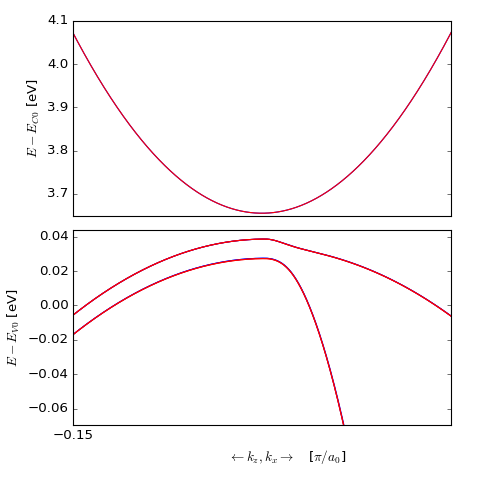

In [65]:
plot_bs(pseudo_k,bs_s_so,color='b')
plot_bs(pseudo_k,bs_s_so_cheat,color='r',new_fig=False)

<IPython.core.display.Javascript object>


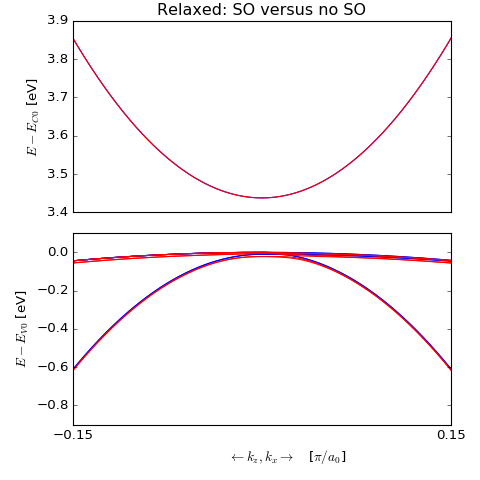

In [66]:
plot_bs(pseudo_k,bs_r_n,color='b')
plot_bs(pseudo_k,bs_r_so,color='r',new_fig=False)
plt.title("Relaxed: SO versus no SO")

<IPython.core.display.Javascript object>


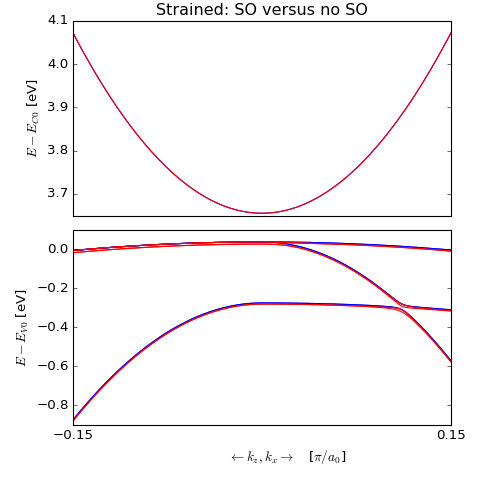

In [10]:
plot_bs(pseudo_k,bs_s_n,color='b')
plot_bs(pseudo_k,bs_s_so,color='r',new_fig=False)
plt.title("Strained: SO versus no SO")

<IPython.core.display.Javascript object>


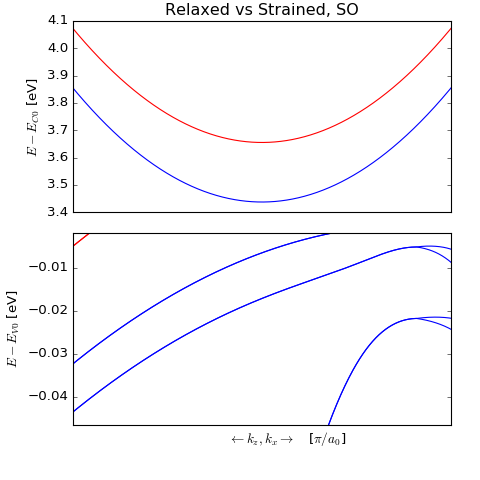

In [67]:
plot_bs(pseudo_k,bs_r_so,color='b')
plot_bs(pseudo_k,bs_s_so,color='r',new_fig=False)
plt.title("Relaxed vs Strained, SO")

<IPython.core.display.Javascript object>


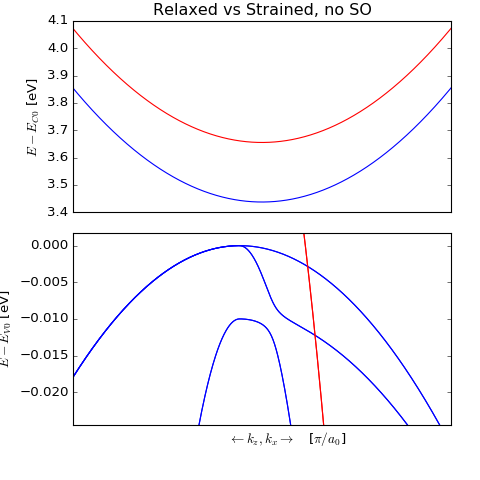

In [68]:
plot_bs(pseudo_k,bs_r_n,color='b')
plot_bs(pseudo_k,bs_s_n,color='r',new_fig=False)
plt.title("Relaxed vs Strained, no SO")

<IPython.core.display.Javascript object>


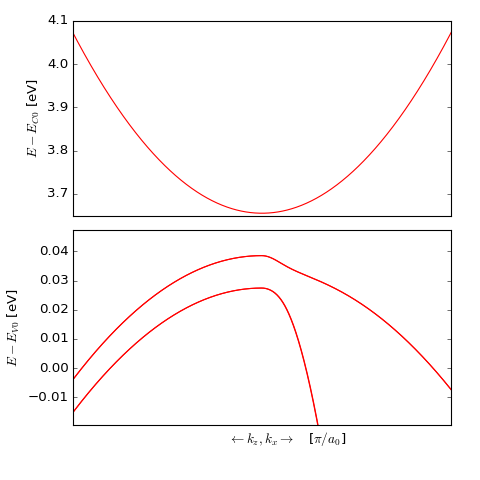

In [69]:
plot_bs(pseudo_k,bs_s_so,color='r')

In [70]:
from scipy import gradient

In [71]:
def print_eff_mass(bs,k,p):
    n=len(k)
    for i in reversed(2*np.arange(3)):
        x=("E0={:7.3f}".format(bs[0,i]))
        x+=("     m={:7.3f}".format(-1/(2*m_e/hbar**2*(bs[p,i]-bs[0,i])/norm(k[p])**2)))
        x+=("     m'={:7.3f}".format(-hbar**2/(m_e*gradient(gradient(bs[:,i]))[p]/(norm(k[1,:])-norm(k[0]))**2)))
        print(x)
def plot_eff_mass(bs,k,i=4):
    #print(bs[:,i])
    m=-1/(2*m_e/hbar**2*(bs[:,i]-bs[0,i])/norm(k,axis=1)**2)
    mp=-hbar**2/(m_e*gradient(gradient(bs[:,i]))/(norm(k[1,:])-norm(k[0,:]))**2)
    print(m)
    print(mp)
    plt.plot(norm(k,axis=1),m)
    plt.plot(norm(k,axis=1),mp,'--')

<IPython.core.display.Javascript object>


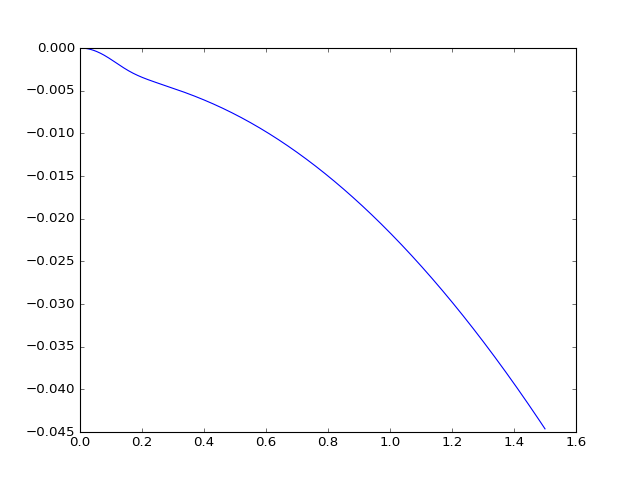

In [75]:
plt.figure()
plt.plot(norm(kvecs[499:],axis=1),(bs_r_so[499:][:,4]))

<IPython.core.display.Javascript object>


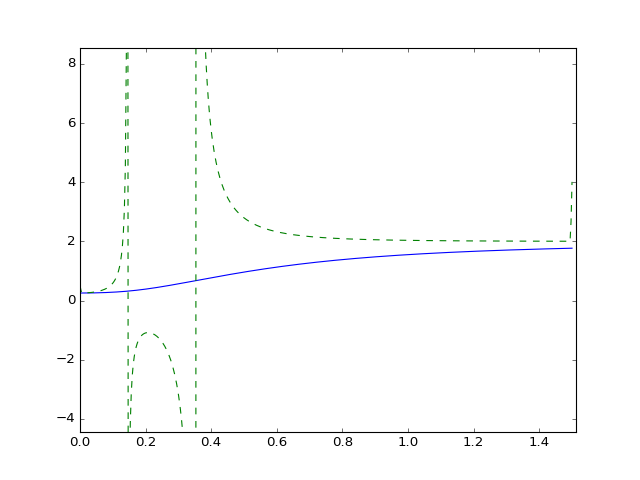

[        nan  0.25688955  0.2569316   0.25702071  0.25715702  0.25734067
  0.25757189  0.25785095  0.25817817  0.25855392  0.25897862  0.25945275
  0.25997681  0.26055139  0.2611771   0.26185461  0.26258463  0.2633679
  0.26420525  0.2650975   0.26604553  0.26705028  0.2681127   0.26923378
  0.27041454  0.27165604  0.27295936  0.27432559  0.27575587  0.27725131
  0.27881306  0.28044228  0.2821401   0.28390769  0.28574618  0.28765669
  0.28964032  0.29169815  0.29383122  0.29604054  0.29832707  0.30069172
  0.30313535  0.30565876  0.30826268  0.31094777  0.3137146   0.31656368
  0.31949543  0.32251017  0.32560814  0.32878949  0.33205426  0.33540241
  0.33883379  0.34234815  0.34594516  0.34962437  0.35338526  0.3572272
  0.36114948  0.36515128  0.36923173  0.37338986  0.37762463  0.38193491
  0.38631954  0.39077725  0.39530675  0.39990668  0.40457562  0.40931213
  0.41411472  0.41898185  0.42391196  0.42890348  0.43395479  0.43906426
  0.44423026  0.44945112  0.45472519  0.46005081  0.4

In [76]:
plt.figure()
plot_eff_mass(bs_s_so[499:],kvecs[499:])

<IPython.core.display.Javascript object>


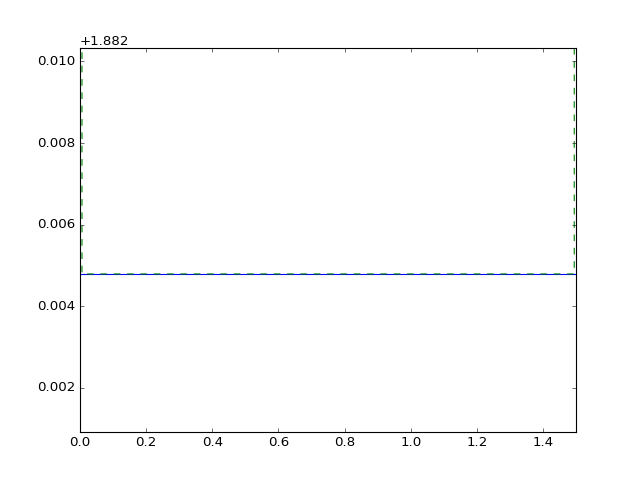

[        nan  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245  1.88679245
  1.88679245  1.88679245  1.88679245  1.88679245  1

In [81]:
plt.figure()
plot_eff_mass(np.flipud(bs_s_so[:500]),np.flipud(kvecs[:500]))

In [40]:
print("no SO")
print("x")
print_eff_mass(np.flipud(bs_r_n[:500]),np.flipud(kvecs[:500]),5)
print("y")
print_eff_mass((bs_r_n[499:]),(kvecs[499:]),5)
print("\n")
print("SO")
print("x")
print_eff_mass(np.flipud(bs_r_so[:500]),np.flipud(kvecs[:500]),5)
print("y")
print_eff_mass((bs_r_so[499:]),(kvecs[499:]),5)

no SO
x
E0=  0.000     m=  1.887     m'=  1.887
E0=  0.000     m=  1.887     m'=  1.887
E0= -0.010     m=  0.139     m'=  0.139
y
E0=  0.000     m=  2.000     m'=  2.000
E0=  0.000     m=  0.146     m'=  0.147
E0= -0.010     m=  1.107     m'=  1.091


SO
x
E0=  0.000     m=  1.887     m'=  1.887
E0= -0.005     m=  0.334     m'=  0.337
E0= -0.022     m=  0.211     m'=  0.209
y
E0=  0.000     m=  0.269     m'=  0.264
E0= -0.005     m=  0.054     m'=  0.322
E0= -0.022     m=  0.057     m'=  0.527


strained
---

In [41]:
print("no SO")
print("x")
print_eff_mass(np.flipud(bs_s_n[:500]),np.flipud(kvecs[:500]),5)
print("y")
print_eff_mass((bs_s_n[499:]),(kvecs[499:]),5)
print("\n")
print("SO")
print("x")
print_eff_mass(np.flipud(bs_s_so[:500]),np.flipud(kvecs[:500]),5)
print("y")
print_eff_mass((bs_s_so[499:]),(kvecs[499:]),5)

no SO
x
E0=  0.039     m=  1.887     m'=  1.887
E0=  0.039     m=  1.887     m'=  1.887
E0= -0.275     m=  0.139     m'=  0.139
y
E0=  0.039     m=  2.000     m'=  2.000
E0=  0.039     m=  0.137     m'=  0.137
E0= -0.275     m=  2.199     m'=  2.199


SO
x
E0=  0.039     m=  1.887     m'=  1.887
E0=  0.027     m=  1.871     m'=  1.871
E0= -0.281     m=  0.139     m'=  0.139
y
E0=  0.039     m=  0.257     m'=  0.260
E0=  0.027     m=  0.210     m'=  0.253
E0= -0.281     m=  0.764     m'=  2.186


strained at 100
---

In [43]:
print("SO")
print("x")
print_eff_mass(np.flipud(bs_s_so[:500]),np.flipud(kvecs[:500]),100)
print("y")
print_eff_mass((bs_s_so[499:]),(kvecs[499:]),100)

SO
x
E0=  0.039     m=  1.887     m'=  1.887
E0=  0.027     m=  1.872     m'=  1.877
E0= -0.281     m=  0.139     m'=  0.139
y
E0=  0.039     m=  0.569     m'= -3.216
E0=  0.027     m=  0.164     m'=  0.124
E0= -0.281     m=  1.983     m'=  2.089


In [23]:
bs_s_so[499][6]-bs_s_so[499][5]

3.6168123414269675

In [24]:
bs_r_so[499][6]-bs_r_so[499][5]

3.4376017699115038

In [25]:
bs_s_so[499][6]-bs_r_so[499][6]

0.21777057126334043

In [26]:
Material("AlN")["Eg"]

6.139999999999999

In [27]:
Material("AlN")["electron.DEc"]-(bs_s_so[499][6]-bs_r_so[499][6])

1.6172294287366593

AlN
===

In [28]:
aln_bs_r_so=kp_6x6(AlN,kvecs,[0,0,0],spin_orbit=True)

In [29]:
plot_bs(pseudo_k,aln_bs_r_so,color='r')
#plot_bs(pseudo_k,bs_r_so,color='r',new_fig=False)
plt.title("Relaxed: SO")# versus no SO")

<IPython.core.display.Javascript object>

In [30]:
print("SO")
print("x")
print_eff_mass(np.flipud(aln_bs_r_so[:500]),np.flipud(kvecs[:500]),100)
print("z")
print_eff_mass((aln_bs_r_so[499:]),(kvecs[499:]),100)

SO
x


NameError: name 'print_eff_mass' is not defined